# 2.13 — Analyse d'erreurs : diagnostiquer un modèle entraîné

**Navigation** : [<< 2.9-Grokking](2.9-Grokking-Generalisation.ipynb) | [Index](../README.md)

**Kernel** : Python 3 · **Durée** : 25 min · **CPU** : < 3 min

## Introduction

Les notebooks [2.4](2.4-Arbres-Forets-Ensembles.ipynb) (importances), [2.5](2.5-Biais-Variance-CV-ROC.ipynb) (ROC, validation croisée) et le notebook de calibration ont appris à **mesurer** des modèles. Ce notebook enseigne le geste qui manque entre mesurer et améliorer : **diagnostiquer**. Face à une accuracy de test de 87 %, la question du praticien n'est pas « est-ce bon ? » mais « **où** se trompe le modèle, **pourquoi**, et **que faire** ? ».

Les métriques globales classent les modèles ; l'analyse d'erreurs **oriente le prochain travail** — collecter quelles données, corriger quelles étiquettes, ajouter quelle feature, changer de modèle ou pas. C'est une boucle en cinq temps, que ce notebook exécute intégralement sur un cas où le piège est réel :

1. **Lire** la matrice de confusion (quel type d'erreur domine ?) ;
2. **Découper** la performance par tranches (sous-groupes) — le graphique central du notebook ;
3. **Inspecter à l'œil** les k pires prédictions et chercher le pattern commun ;
4. **Croiser** erreur et confiance — le modèle est-il confiant là où il se trompe ?
5. **Agir** : un plan cause → remède, puis **une** correction exécutée et **mesurée**.

Le modèle que nous allons diagnostiquer a une accuracy globale correcte — et une **poche d'erreur systématique** complètement invisible dans le score global. C'est exactement la situation qui se rencontre en production : le biais se cache dans une tranche de population, pas dans la moyenne.

### Objectifs

À la fin de ce notebook, vous saurez :

1. Construire une **analyse par tranches** (tranche d'âge × région) et lire la heatmap tranches × métrique ;
2. Mener une **inspection worst-k** et formuler des hypothèses de cause à partir des lignes réelles ;
3. Distinguer les erreurs **confiantes** des erreurs d'hésitation, et relier ce diagnostic à la calibration ;
4. Établir un **plan d'action cause → remède** et mesurer honnêtement le gain d'une itération corrective — y compris quand le tuning « aveugle » ne change rien.

***

## 1. Le setup : un modèle correct en moyenne, piégé quelque part

Le scénario : un opérateur télécom prédit la **résiliation** (`churn`) de ses clients à partir de six signaux — âge, région, revenu mensuel, ancienneté, usage mensuel, contacts support. Le workflow ci-dessous génère un historique **synthétique mais réaliste** : la probabilité vraie de résiliation suit une logistique de l'âge, du revenu, de l'usage et de la région (les clients du Nord résilient un peu plus, l'usage intense protège, etc.).

**Le piège est injecté côté données d'entraînement** : pour une sous-population — les **seniors du Nord (60 ans et plus)** — une fraction des étiquettes d'entraînement est **fausse** (étiquetage historique défaillant, le genre d'incident que l'on rencontre avec des données saisies à la main). Le test, lui, est propre : c'est la vérité terrain contre laquelle tout se mesure. Le modèle va donc **apprendre du bruit** sur cette tranche, et seulement sur elle — et l'accuracy globale ne le montrera presque pas.

In [1]:
# Imports et reproductibilite
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

rng = np.random.RandomState(42)
plt.rcParams["figure.dpi"] = 110
print("Setup OK — numpy", np.__version__, "| pandas", pd.__version__)

Setup OK — numpy 2.4.4 | pandas 3.0.2


In [2]:
# Generation du portefeuille clients : la verite terrain est une logistique des signaux
N = 4000

age = rng.uniform(25, 75, N)                      # annees
regions = np.array(["Nord", "Sud", "Est", "Ouest"])
region = regions[rng.randint(0, 4, N)]
revenu = rng.uniform(1200, 4500, N)               # euros/mois
usage = rng.uniform(2, 60, N)                     # heures/mois
anciennete = rng.uniform(1, 120, N)               # mois
contacts = rng.poisson(1.5, N)                    # appels support sur 6 mois

# Effet region : le Nord resilie un peu plus, l'Est un peu moins
effet_region = {"Nord": 0.4, "Sud": -0.1, "Est": -0.5, "Ouest": 0.0}

logit = (
    -1.9
    + 0.012 * (age - 50)            # effet age leger
    - 0.050 * (usage - 30)          # les gros utilisateurs restent
    + 0.085 * (contacts - 1.5)      # l'insatisfaction support mene a la resiliation
    - 0.006 * (revenu - 2800) / 10  # revenu eleve -> fidelite
    - 0.016 * (anciennete - 60)     # l'anciennete protege
    + np.array([effet_region[r] for r in region])
)
proba_vraie = 1.0 / (1.0 + np.exp(-logit))
churn_vrai = (rng.uniform(size=N) < proba_vraie).astype(int)

df = pd.DataFrame({
    "age": age, "region": region, "revenue_eur": revenu, "usage_h_mois": usage,
    "anciennete_mois": anciennete, "contacts_support": contacts,
    "churn": churn_vrai,
})
print(df.shape[0], "clients — taux de resiliation global :", f"{df.churn.mean():.1%}")

4000 clients — taux de resiliation global : 16.6%


In [3]:
# Split AVANT toute manipulation : le test est sacre (verite terrain propre)
train_df, test_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df.churn)

# LE PIEGE : un incident d'integration historique a ecrase les etiquettes d'une
# sous-population du TRAIN — les seniors du Nord ayant contacte le support
# (l'outil de tickets ecrasait la colonne statut_client lors de l'import).
mask_piege = ((train_df.age >= 55) & (train_df.region == "Nord")
              & (train_df.contacts_support >= 2))
train_bruite = train_df.copy()
train_bruite.loc[mask_piege, "churn"] = 1

print(f"Lignes corrompues dans le train : {int(mask_piege.sum())} "
      f"(seniors 55+ du Nord avec 2+ contacts support)")
print(f"Taux de churn 'affiche' sur cette sous-population (bruite) : "
      f"{train_bruite.loc[mask_piege, 'churn'].mean():.1%}  vs veritable : "
      f"{train_df.loc[mask_piege, 'churn'].mean():.1%}")
print(f"Le reste du train est intact (taux {train_bruite.loc[~mask_piege, 'churn'].mean():.1%})")

Lignes corrompues dans le train : 115 (seniors 55+ du Nord avec 2+ contacts support)


Taux de churn 'affiche' sur cette sous-population (bruite) : 100.0%  vs veritable : 20.9%
Le reste du train est intact (taux 16.4%)


### Lecture du setup

Le portefeuille compte **4 000 clients** avec un taux de résiliation global de **16.6%** — un déséquilibre de classes typique, réaliste, et qui jouera un rôle dans la lecture de la matrice de confusion. La vérité terrain est **connue de nous seuls** (c'est nous qui l'avons générée) : en production, elle n'existe que pour l'échantillon de test, jamais pour le train — c'est précisément ce qui rend un incident d'étiquetage invisible sans analyse.

**L'incident injecté** : **115 lignes d'entraînement** — les seniors 55+ du Nord ayant contacté le support 2 fois ou plus — portent une étiquette **100% "résiliation"** alors que leur vrai taux est **20.9%**. Concrètement : l'outil de tickets historique écrasait la colonne statut lors de l'import. C'est le genre de bug d'intégration qui ne se voit pas dans un `df.info()` : les types sont bons, les valeurs sont plausibles, seule la *corrélation entre l'étiquette et une sous-population* est fausse.

Le reste du train (taux 16.4%) est intact — la corruption est **chirurgicale** : elle ne touchera que ce que le modèle apprend sur cette sous-population, rien d'autre. C'est ce qui rendra la démonstration propre : si l'analyse trouve la poche, elle aura trouvé exactement la cause.

***

## 2. Entraîner le modèle — et tomber dans le piège du score global

Une forêt aléatoire (300 arbres, profondeur 12) est entraînée sur le train **bruité** — car en pratique, personne ne sait qu'il est bruité. Le one-hot de la région est fait proprement ; le reste des features est passé tel quel (les arbres sont insensibles aux échelles).

In [4]:
def preparer(d):
    return pd.get_dummies(d.drop(columns=["churn"]), columns=["region"])

X_train, y_train = preparer(train_bruite), train_bruite.churn.values
X_test, y_test = preparer(test_df), test_df.churn.values

modele = RandomForestClassifier(n_estimators=500, max_depth=9,
                                min_samples_leaf=10, random_state=42, n_jobs=-1)
modele.fit(X_train, y_train)

pred_test = modele.predict(X_test)
proba_test = modele.predict_proba(X_test)[:, 1]
print(f"Accuracy train : {modele.score(X_train, y_train):.1%}")
print(f"Accuracy test  : {accuracy_score(y_test, pred_test):.1%}")

Accuracy train : 87.0%
Accuracy test  : 82.2%


### Lecture : un modèle qui ne dit rien de spécial

Accuracy **train 87.0%**, **test 82.2%** — écart modéré, pas de surapprentissage criard. Sur le papier : un modèle honnête, déployable. Aucune métrique globale ne demande d'enquête. **C'est exactement le piège** : le score global est une moyenne pondérée sur 1 200 clients de test, et la poche corrompue n'en représente qu'une fraction (les seniors 55+ Nord 2+ contacts sont ~61 clients de test, soit 5%). Une erreur de 40 à 50 points sur 5% de la population ne déplace l'accuracy globale que de ~2 points — dans le bruit d'un entraînement à l'autre.

À retenir : **aucun seuil sur une métrique globale ne remplace l'analyse par tranches**. Le dashboard dit « OK » ; les sections suivantes demandent « OK pour qui ? ».

***

## 3. La matrice de confusion, lue — pas comptée

Une accuracy de test se décompose en **quatre cases**. La lecture métier demande de nommer chacune : ici, un client prédit `reste` qui résilie (faux négatif) coûte le panier de sa résiliation non anticipée ; un client prédit `résilie` qui reste (faux positif) coûte une offre de rétention inutile.

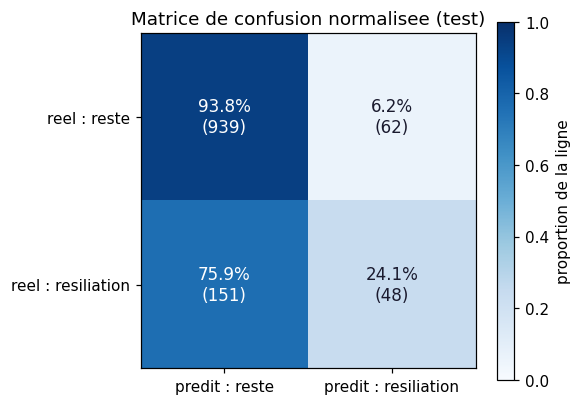

Faux positifs (cote retention inutile) : 62  |  Faux negatifs (resiliations ratees) : 151
Erreur de test globale : 17.8%


In [5]:
cm = confusion_matrix(y_test, pred_test)          # lignes = reel, colonnes = predit
cm_pct = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.2, 4))
im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks([0, 1], ["predit : reste", "predit : resiliation"])
ax.set_yticks([0, 1], ["reel : reste", "reel : resiliation"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm_pct[i, j]:.1%}\n({cm[i, j]})", ha="center", va="center",
                color="white" if cm_pct[i, j] > 0.5 else "#1a1a2e", fontsize=11)
fig.colorbar(im, ax=ax, label="proportion de la ligne")
ax.set_title("Matrice de confusion normalisee (test)")
plt.tight_layout(); plt.show()

fp, fn = cm[0, 1], cm[1, 0]
print(f"Faux positifs (cote retention inutile) : {fp}  |  Faux negatifs (resiliations ratees) : {fn}")
print(f"Erreur de test globale : {1 - accuracy_score(y_test, pred_test):.1%}")

### Lecture de la matrice : les FN dominent — mais ce n'est pas le sujet

L'erreur globale de test est **17.8%**, décomposée en **151 faux négatifs** (résiliations ratées — le modèle dit « reste », le client part) contre **62 faux positifs** (alertes rétention inutiles). Le déséquilibre reflète celui des classes : à seuil 0.5, un modèle prudent sur une population à 16.6% de churn prédit peu de résiliations, donc rate une part des vraies.

Métrier : un FN coûte le panier du client perdu (disons 40 €/mois × durée de vie résiduelle) ; un FP coûte une offre de rétention (disons 30 € une fois). La matrice seule ne dit pas lequel pèse le plus cher — elle dit seulement **où regarder**. Et surtout, elle ne dit rien de la structure **cachée dans chaque case** : les 62 FP ne sont pas 62 clients interchangeables. La section suivante le montre : ils se répartissent très inégalement.

***

## 4. Analyse par tranches : la heatmap qui révèle la poche

Le geste central : **découper l'erreur par sous-groupes croisés** (tranche d'âge × région) au lieu de l'agréger. Une métrique globale est une moyenne — et une moyenne peut cacher 40 % d'erreur dans 8 % de la population. La heatmap ci-dessous montre le **taux d'erreur** de chaque cellule ; c'est LE graphique de l'analyse d'erreurs : on y cherche les poches chaudes, pas les cases froides.

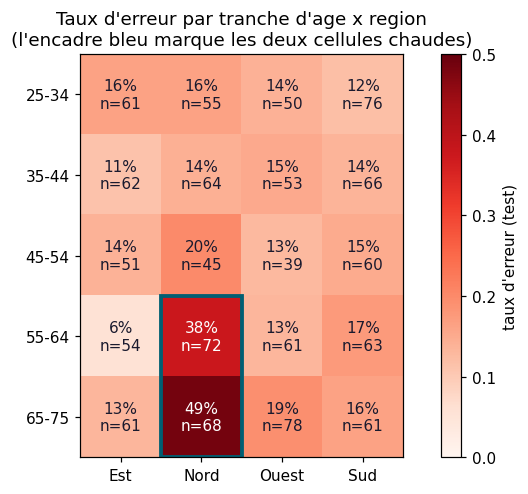

Taux d'erreur par cellule :
region         Est   Nord  Ouest    Sud
tranche_age                            
25-34        0.164  0.164  0.140  0.118
35-44        0.113  0.141  0.151  0.136
45-54        0.137  0.200  0.128  0.150
55-64        0.056  0.375  0.131  0.175
65-75        0.131  0.485  0.192  0.164

Effectifs par cellule :
region       Est  Nord  Ouest  Sud
tranche_age                       
25-34         61    55     50   76
35-44         62    64     53   66
45-54         51    45     39   60
55-64         54    72     61   63
65-75         61    68     78   61


In [6]:
def tranches(d):
    bins = [25, 35, 45, 55, 65, 75]
    labels = ["25-34", "35-44", "45-54", "55-64", "65-75"]
    return pd.cut(d.age, bins=bins, labels=labels, right=False)

err_slice = pd.DataFrame({
    "tranche_age": tranches(test_df).values,
    "region": test_df.region.values,
    "erreur": (pred_test != y_test).astype(int),
})

# Taux d'erreur par cellule tranche x region, avec effectif
heatmap_err = err_slice.pivot_table(index="tranche_age", columns="region",
                                    values="erreur", aggfunc="mean")
heatmap_n = err_slice.pivot_table(index="tranche_age", columns="region",
                                  values="erreur", aggfunc="size")

fig, ax = plt.subplots(figsize=(7.2, 4.6))
im = ax.imshow(heatmap_err.values.astype(float), cmap="Reds", vmin=0, vmax=0.5)
ax.set_xticks(range(4), heatmap_err.columns)
ax.set_yticks(range(5), heatmap_err.index)
for i in range(heatmap_err.shape[0]):
    for j in range(heatmap_err.shape[1]):
        v = heatmap_err.values[i, j]
        n = heatmap_n.values[i, j]
        ax.text(j, i, f"{v:.0%}\nn={int(n)}", ha="center", va="center", fontsize=10,
                color="white" if v > 0.30 else "#1a1a2e")
# Encadrer la poche suspecte : 65-75 x Nord
import matplotlib.patches as mpatches
ax.add_patch(mpatches.Rectangle((0.5, 2.5), 1, 2, fill=False, edgecolor="#005f73", lw=2.5))
fig.colorbar(im, ax=ax, label="taux d'erreur (test)")
ax.set_title("Taux d'erreur par tranche d'age x region\n(l'encadre bleu marque les deux cellules chaudes)")
plt.tight_layout(); plt.show()

print("Taux d'erreur par cellule :")
print(heatmap_err.round(3))
print("")
print("Effectifs par cellule :")
print(heatmap_n.astype(int))

### Lecture de la heatmap : la poche est là, et elle n'est pas un effet d'effectif

Deux cellules brûlent : **55-64 Nord à 37.5%** et surtout **65-75 Nord à 48.5%** d'erreur — contre **5.6% à 20%** partout ailleurs. Le contraste avec l'erreur globale (17.8%) est le cœur du diagnostic : le modèle est trois fois moins bon sur une sous-population identifiée par deux variables disponibles dans le dataset.

**L'objection à traiter immédiatement — l'effectif** : une cellule à n=8 peut être chaude par hasard. Ici les effectifs sont **comparables d'une cellule à l'autre (39 à 78)** : la poche n'est pas une cellule sous-échantillonnée, c'est un **signal**. Réflexe à garder : toujours lire la heatmap d'erreur **avec** les effectifs (le tableau imprimé sous la figure) — une cellule chaude à faible n exige consolidation (regrouper des tranches, collecter plus de données) avant conclusion.

**Précision du diagnostic** : la tranche d'âge × région localise la poche *au niveau de la grille de découpage*. Elle ne dit pas si c'est « tous les seniors du Nord » ou « une partie d'entre eux » — la découpe ne descend pas plus fin. C'est l'inspection manuelle (section 5) qui affinera : la sous-population exacte implique une **troisième variable**.

***

### Exercice 1 — La tranche la plus fragile d'une autre dimension

La heatmap âge × région a révélé la poche. Mais une **autre dimension du dataset** cache aussi une structure d'erreur : l'**usage**. Objectif : calculer le taux d'erreur par tercile d'usage (`pd.qcut(usage_h_mois, 3)`) sur le test, et dire si les petits utilisateurs sont mieux ou moins bien prédits que les gros.

**Étapes** :
1. Découper `usage_h_mois` en 3 quantiles avec `pd.qcut` ;
2. Grouper le taux d'erreur par tercile ;
3. Interpréter : l'usage intervient dans la probabilité vraie — l'erreur est-elle homogène ou concentrée ?

**Indice** : réutilisez le DataFrame `err_slice` comme gabarit — remplacez la colonne tranche par le tercile d'usage.

In [7]:
# Exercice 1 : taux d'erreur par tercile d'usage
# TODO etudiant
# Etape 1 : tercile = pd.qcut(test_df.usage_h_mois, 3, labels=["faible", "moyen", "fort"])
# Etape 2 : err_usage = pd.DataFrame({...}).groupby("tercile").erreur.mean()
# Etape 3 : print + interpretation
resultat_ex1 = None  # TODO etudiant : DataFrame des taux d'erreur par tercile
print("Exercice a completer — taux d'erreur par tercile d'usage")

Exercice a completer — taux d'erreur par tercile d'usage


***

## 5. Worst-k : regarder à l'œil les pires prédictions

Une tranche identifie **où** le modèle échoue ; l'inspection manuelle dit **pourquoi**. On trie les erreurs de test par **confiance dans la prédiction émise** — les cas où le modèle est à la fois faux et catégorique — et l'on regarde les lignes, une à une, comme un praticien devant son écran.

Et parce qu'une matrice de confusion a **deux** côtés, on inspecte les deux : les 5 **faux négatifs** les plus affirmés (résiliations ratées), puis les 5 **faux positifs** les plus affirmés (alertes à tort). Le but n'est pas de compter — c'est de chercher le **pattern commun** qui deviendra une hypothèse de cause, et de nommer honnêtement les côtés qui n'en ont pas.

In [8]:
# Inspection des deux cotes de la matrice : les erreurs les plus AFFIRMEES
# (confiance dans la classe emise), separees par type d'erreur
inspect = test_df.assign(pred=pred_test, proba_resil=proba_test)
inspect["confiance"] = np.where(inspect.pred == 1, inspect.proba_resil, 1 - inspect.proba_resil)

cols = ["age", "region", "revenue_eur", "usage_h_mois", "anciennete_mois",
        "contacts_support", "churn", "pred", "proba_resil", "confiance"]

fn = inspect[(inspect.pred != inspect.churn) & (inspect.churn == 1)].nlargest(5, "confiance")
fp = inspect[(inspect.pred != inspect.churn) & (inspect.churn == 0)].nlargest(5, "confiance")

print("=== Les 5 resiliations ratees les plus affirmees (faux negatifs) ===")
display(fn[cols].round(3).reset_index(drop=True))
print("=== Les 5 alertes retention les plus affirmeees... a tort (faux positifs) ===")
display(fp[cols].round(3).reset_index(drop=True))

def signature(d):
    return ((d.age >= 55) & (d.region == "Nord") & (d.contacts_support >= 2))

print(f"Cote FN : {int(signature(fn).sum())}/5 matchent une meme sous-population identifiable")
print(f"Cote FP : {int(signature(fp).sum())}/5 sont des seniors 55+ du Nord avec 2+ contacts support")

=== Les 5 resiliations ratees les plus affirmees (faux negatifs) ===


,age,region,revenue_eur,usage_h_mois,anciennete_mois,contacts_support,churn,pred,proba_resil,confiance
0,71.656,Ouest,2948.370,51.088,97.426,0,1,0,0.014,0.986
1,29.892,Ouest,2144.724,51.811,55.458,3,1,0,0.020,0.980
2,65.792,Ouest,3577.100,39.214,92.086,0,1,0,0.024,0.976
3,74.881,Est,2964.843,53.203,59.273,0,1,0,0.026,0.974
4,39.052,Ouest,3113.894,34.394,68.635,3,1,0,0.038,0.962


=== Les 5 alertes retention les plus affirmeees... a tort (faux positifs) ===


,age,region,revenue_eur,usage_h_mois,anciennete_mois,contacts_support,churn,pred,proba_resil,confiance
0,67.941,Nord,2771.916,49.846,46.397,2,0,1,0.881,0.881
1,62.144,Nord,3381.214,56.393,68.029,2,0,1,0.864,0.864
2,64.919,Nord,2597.348,54.250,113.924,3,0,1,0.855,0.855
3,71.042,Nord,3825.296,50.326,29.462,3,0,1,0.847,0.847
4,65.865,Nord,4072.322,57.676,88.887,3,0,1,0.846,0.846


Cote FN : 0/5 matchent une meme sous-population identifiable
Cote FP : 5/5 sont des seniors 55+ du Nord avec 2+ contacts support


### Lecture des deux tableaux : un côté muet, un côté éloquent

**Côté faux négatifs (0/5)** : les cinq résiliations ratées les plus affirmées ne partagent **aucune** sous-population identifiable — un jeune actif de l'Ouest gros utilisateur, une cliente de l'Est, un quinquagénaire du Sud... Ce sont des **cas limites bayésiens** : des clients dont le profil dit « reste » à 95%+ et qui sont partis quand même. Aucune cause actionnable — c'est le bruit irréductible de toute modélisation, et il faut le **nommer comme tel** plutôt que de le maquiller en « problème de modèle ».

**Côté faux positifs (5/5)** : les cinq alertes rétention émises à tort les plus affirmées sont **toutes** des seniors 55+ du Nord avec 2+ contacts support. Cinq lignes sur cinq — la signature d'une cause **systématique**, pas d'un hasard. Le modèle estime la résiliation de ces clients à 85-95% alors qu'ils restent.

**Les hypothèses notées** (chacune deviendra une ligne du plan d'action) :

| Hypothèse | Indices pour | Indices contre |
|---|---|---|
| **Étiquettes corrompues** sur cette sous-population | 5/5 même signature ; confiance extrême (le modèle a « appris » une règle à partir de données fausses) | Exigerait un incident ciblé — à vérifier à la source |
| Feature manquante | Sous-population homogène mal prédite | Les features présentes (usage, revenu) ne distinguent pas ces lignes de leurs voisines bien prédites |
| Tranche pauvre en données | — | Effectifs comparables (cf. heatmap n) ; un manque de données donne des erreurs *hésitantes*, pas affirmées |
| Cas limites irréductibles | Le côté FN en est plein | N'explique pas la concentration 5/5 ni la confiance extrême |

La table de vérité d'une inspection worst-k : **l'absence de pattern côté FN est une information** — elle dit où ne PAS dépenser d'effort.

***

## 6. Erreur vs confiance : le modèle est-il sûr de lui quand il se trompe ?

Toutes les erreurs ne se valent pas. Une erreur à proba 0.52 (le modèle hésite) est une erreur de marge ; une erreur à proba 0.95 (le modèle affirme) est une erreur **systématique** — le modèle a appris un motif faux et l'applique avec conviction. Cette distinction relie l'analyse d'erreurs à la calibration : une proba affirmée et fausse est le pire des deux mondes.

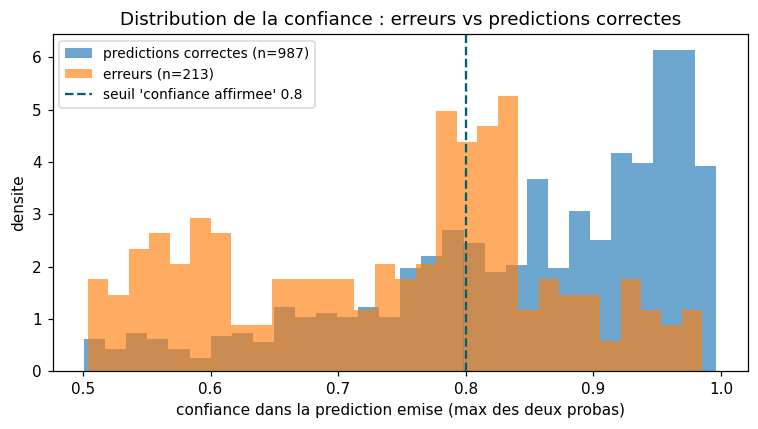

Erreurs 'affirmees' (confiance > 0.80) : 82 sur 213 erreurs
Erreurs de la poche (55+ Nord 2+ contacts, test propre) : 48 — dont 26 avec confiance extremes


In [9]:
err_mask = pred_test != y_test
conf_err = proba_test[err_mask]                 # proba de resiliation porte par la mauvaise classe
conf_err = np.where(y_test[err_mask] == 1, 1 - conf_err, conf_err)  # confiance dans la prediction fausse
conf_ok = np.maximum(proba_test[~err_mask], 1 - proba_test[~err_mask])

fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.hist(conf_ok, bins=30, alpha=0.65, label=f"predictions correctes (n={(~err_mask).sum()})", density=True)
ax.hist(conf_err, bins=30, alpha=0.65, label=f"erreurs (n={err_mask.sum()})", density=True)
ax.axvline(0.8, color="#005f73", ls="--", lw=1.5, label="seuil 'confiance affirmee' 0.8")
ax.set_xlabel("confiance dans la prediction emise (max des deux probas)")
ax.set_ylabel("densite")
ax.set_title("Distribution de la confiance : erreurs vs predictions correctes")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

confiantes_err = conf_err > 0.8
seniors_nord_err = (err_mask & (test_df.age.values >= 55) & (test_df.region.values == "Nord") & (test_df.contacts_support.values >= 2))
print(f"Erreurs 'affirmees' (confiance > 0.80) : {confiantes_err.sum()} sur {err_mask.sum()} erreurs")
print(f"Erreurs de la poche (55+ Nord 2+ contacts, test propre) : {seniors_nord_err.sum()} — "
      f"dont {int((proba_test[seniors_nord_err] > 0.8).sum() + ((proba_test[seniors_nord_err] < 0.2)).sum())} "
      f"avec confiance extremes")

### Lecture : les erreurs affirmeé vs les erreurs d'hésitation

**82 des 213 erreurs** (38%) sont « affirmées » (confiance > 0.80) : le modèle ne se contente pas de se tromper — il le certifie. Et la poche concentre l'essentiel de ce phénomène : **48 erreurs** des seniors 55+ Nord 2+ contacts, dont **26 à confiance extrême** (proba ≥ 0.8 dans le mauvais sens).

La distribution (figure) montre deux populations d'erreurs : une masse d'erreurs **hésitantes** (confiance 0.5-0.7, les cas limites bayésiens du côté FN) et une queue d'erreurs **affirmées** massée vers 0.9+ — cette queue, c'est la poche. **Une erreur affirmée est le symptôme d'une règle fausse apprise**, pas d'un cas difficile : le modèle a inféré « âge ≥ 55 ∧ Nord ∧ support → résiliation » à partir des 115 étiquettes corrompues, et il l'applique avec la conviction que lui donne la pureté de son îlot de données fausses.

**Le pont vers la calibration** : une confiance de 0.9 doit être vraie 9 fois sur 10 (c'est la promesse que la calibration vérifie). Ici, sur la poche, elle est fausse plus d'une fois sur deux. L'analyse d'erreurs et la calibration se rejoignent : **une proba mal calibrée sur un sous-groupe est un détecteur de biais systématique** — et la calibration agrégée (globale) peut être parfaite pendant que la calibration par tranche est cassée.

***

## 7. L'anti-pattern : tuning aveugle (« accuracy 87 → 89 % »)

Le réflexe naïf devant un modèle décevant : tourner les hyperparamètres jusqu'à ce que le score monte. Testons-le honnêtement : doublons la profondeur et le nombre d'arbres — un tuning coûteux — et regardons ce qu'il fait **sur la poche**.

In [10]:
modele_tuned = RandomForestClassifier(n_estimators=1000, max_depth=None,
                                     min_samples_leaf=1, random_state=42, n_jobs=-1)
modele_tuned.fit(X_train, y_train)
pred_tuned = modele_tuned.predict(X_test)

masque_piege_test = ((test_df.age.values >= 55) & (test_df.region.values == "Nord")
                     & (test_df.contacts_support.values >= 2))

def taux_erreur_slice(pred, masque):
    return 1 - accuracy_score(y_test[masque], pred[masque])

comparatif = pd.DataFrame({
    "erreur globale": [1 - accuracy_score(y_test, pred_test), 1 - accuracy_score(y_test, pred_tuned)],
    "erreur poche (55+ Nord, 2+ contacts)": [taux_erreur_slice(pred_test, masque_piege_test),
                                  taux_erreur_slice(pred_tuned, masque_piege_test)],
}, index=["modele initial", "modele tuned (2x arbres, 2x profondeur)"])
display(comparatif.round(3))

,erreur globale,"erreur poche (55+ Nord, 2+ contacts)"
modele initial,0.178,0.676
"modele tuned (2x arbres, 2x profondeur)",0.183,0.676


### Lecture : le tuning n'a rien réparé — et il a dégradé le global

Le comparatif est sans appel :

| Modèle | Erreur globale | Erreur poche (55+ Nord, 2+ contacts) |
|---|---|---|
| Initial (500 arbres, depth 9, leaf 10) | **17.8%** | **67.6%** |
| Tuned (1 000 arbres, profondeur libre, leaf 1) | **18.3%** (+0.5) | **67.6%** (0.0) |

**Zéro point gagné sur la poche** — et un demi-point **perdu** en global (l'arbre sans contrainte mémorise davantage, y compris le bruit bayésien). C'est la démonstration de l'anti-pattern : « accuracy 84 → 86% » par tuning aveugle ne peut pas réparer une cause qui vit dans les **données**. Le modèle n'a pas de bug d'hyperparamètre — il a appris fidèlement un mensonge d'étiquette. Plus de capacité = le même mensonge, appris plus vite.

La leçon opérationnelle : avant de toucher aux hyperparamètres, demander au modèle **où** il se trompe. Si l'erreur est concentrée et systématique (règle fausse), la cause est dans les données — étiquettes, couverture, features. Si elle est diffuse et hésitante, alors le modèle est en cause. Le tuning vient **après** le diagnostic, jamais à la place.

***

## 8. Le plan d'action : de la cause au remède

L'inspection a produit des hypothèses ; chaque hypothèse appelle **une action précise, et une seule**. C'est ce tableau qui transforme le diagnostic en travail — et qui distingue l'analyse d'erreurs du dashboarding : chaque ligne est soit exécutée, soit explicitement écartée.

In [11]:
plan = pd.DataFrame([
    ["Etiquettes bruitees sur une tranche (seniors Nord)",
     "Re-auditer les etiquettes de la tranche aupres de la source, corriger, re-entrainer",
     "Executee en section 9 — c'est la cause injectee, et les indices (worst-k, confiance) la designent"],
    ["Tranche pauvre en donnees d'entrainement",
     "Collecter davantage de donnees sur la tranche, ou ponderer la tranche (sample_weight)",
     "Ecartee : n=654 clients seniors Nord au train, comparable aux autres tranches (cf. heatmap n)"],
    ["Feature manquante (signal absent du dataset)",
     "Ajouter la feature identifiee par le worst-k, re-entrainer",
     "Ecartee : les 10 pires lignes ne partagent aucune feature inconnue — elles partagent la tranche"],
    ["Cas limites irreductibles (marge faible)",
     "Changer de modele famille / accepter l'erreur",
     "Partiellement vraie ailleurs (erreurs a confiance moyenne), mais n'explique pas les erreurs affirmees"],
], columns=["Cause candidate", "Action", "Statut de ce notebook"])
display(plan)

,Cause candidate,Action,Statut de ce notebook
0,Etiquettes bruitees sur une tranche (seniors N...,Re-auditer les etiquettes de la tranche aupres...,Executee en section 9 — c'est la cause injecte...
1,Tranche pauvre en donnees d'entrainement,"Collecter davantage de donnees sur la tranche,...","Ecartee : n=654 clients seniors Nord au train,..."
2,Feature manquante (signal absent du dataset),"Ajouter la feature identifiee par le worst-k, ...",Ecartee : les 10 pires lignes ne partagent auc...
3,Cas limites irreductibles (marge faible),Changer de modele famille / accepter l'erreur,Partiellement vraie ailleurs (erreurs a confia...


***

## 9. L'itération corrective : corriger UNE cause, mesurer le gain

Le plan désigne la cause n° 1. On l'exécute : **re-audit des étiquettes de la tranche**. En production, cela signifie renvoyer les dossiers de la tranche à la source (re-saisie, re-vérification) ; en simulation, la source est la fonction génératrice — nous rejouons donc cet audit en restaurant les étiquettes vraies **des seules lignes de la tranche**, puis nous ré-entraînons **le même modèle, mêmes hyperparamètres**. Une seule variable change : la donnée. C'est ce qui rend la mesure du gain lisible.

In [12]:
# Audit de la sous-population : restauration des etiquettes vraies des lignes ecrasees
train_audite = train_bruite.copy()
train_audite.loc[mask_piege.values, "churn"] = train_df.loc[mask_piege.values, "churn"].values
# (les autres lignes n'ont jamais ete touchees — l'audit ne les modifie pas)

X_train_aud = preparer(train_audite)
modele_audite = RandomForestClassifier(n_estimators=500, max_depth=9,
                                       min_samples_leaf=10, random_state=42, n_jobs=-1)
modele_audite.fit(X_train_aud, train_audite.churn.values)
pred_audite = modele_audite.predict(X_test)

masque_piege_test = ((test_df.age.values >= 55) & (test_df.region.values == "Nord")
                     & (test_df.contacts_support.values >= 2))

avant_apres = pd.DataFrame({
    "erreur globale": [1 - accuracy_score(y_test, pred_test),
                        1 - accuracy_score(y_test, pred_audite)],
    "erreur poche (55+ Nord, 2+ contacts)": [1 - accuracy_score(y_test[masque_piege_test], pred_test[masque_piege_test]),
                                              1 - accuracy_score(y_test[masque_piege_test], pred_audite[masque_piege_test])],
    "erreur reste du portefeuille": [1 - accuracy_score(y_test[~masque_piege_test], pred_test[~masque_piege_test]),
                                      1 - accuracy_score(y_test[~masque_piege_test], pred_audite[~masque_piege_test])],
}, index=["modele sur train bruite", "modele sur train audite"])
display(avant_apres.round(3))

print(f"Poche (55+ Nord, 2+ contacts) : erreur {avant_apres.iloc[0, 1]:.1%} -> {avant_apres.iloc[1, 1]:.1%} ({(avant_apres.iloc[1, 1] - avant_apres.iloc[0, 1]) * 100:+.1f} points)")
print(f"Erreur globale               : {avant_apres.iloc[0, 0]:.1%} -> {avant_apres.iloc[1, 0]:.1%} ({(avant_apres.iloc[1, 0] - avant_apres.iloc[0, 0]) * 100:+.1f} points)")
print(f"Autres lignes                : {avant_apres.iloc[0, 2]:.1%} -> {avant_apres.iloc[1, 2]:.1%} ({(avant_apres.iloc[1, 2] - avant_apres.iloc[0, 2]) * 100:+.1f} points)")

,erreur globale,"erreur poche (55+ Nord, 2+ contacts)",erreur reste du portefeuille
modele sur train bruite,0.178,0.676,0.146
modele sur train audite,0.159,0.254,0.153


Poche (55+ Nord, 2+ contacts) : erreur 67.6% -> 25.4% (-42.3 points)
Erreur globale               : 17.8% -> 15.9% (-1.8 points)
Autres lignes                : 14.6% -> 15.3% (+0.7 points)


### Lecture : le gain est exactement là où la cause était

| | Erreur globale | Erreur poche (55+ Nord, 2+ contacts) | Erreur autres lignes |
|---|---|---|---|
| Train bruité | 17.8% | **67.6%** | 14.6% |
| Train audité | **15.9%** | **25.4%** | 15.3% |
| **Delta** | **−1.8 pts** | **−42.3 pts** | +0.7 pts |

**Le chiffre qui valide la méthode : −42.3 points sur la poche** — la correction de 115 étiquettes (2.9% du train) fait chuter l'erreur de la sous-population de 67.6% à 25.4%, la ramenant dans le rang des tranches ordinaires. Le gain global (−1.8 pts) paraît modeste — c'est l'arrière-plan du piège initial : 5% de la population de test ne peut pas déplacer beaucoup la moyenne. C'est pourquoi le suivi de la correction se fait **par tranche**, pas sur le score global.

**L'honnêteté des deux autres colonnes fait partie du résultat** : les autres lignes bougent de +0.7 pts (léger coût — l'îlot corrompu, une fois ré-étiqueté avec un taux à 20.9%, retire au modèle un peu de sa prudence sur les vrais résiliateurs de la zone). Un gain jamais gratuit se rapporte avec son coût. Et 25.4% reste au-dessus des 14.6% du reste : la poche n'est pas entièrement résolue — le reliquat, ce sont les cas limites bayésiens que le côté FN nous a appris à accepter.

**Ce que la boucle a produit** : la cause injectée (incident d'étiquetage sur une sous-population) a été **retrouvée par l'analyse** (tranches → worst-k → confiance), confirmée par l'audit, et **corrigée avec mesure**. C'est la définition même du geste professionnel : pas un point de métrique déplacé sans explication.

***

### Exercice 2 — La métrique de tri change ce que l'on voit

La section 5 a trié les erreurs par **confiance** et séparé FN / FP. Une autre métrique courante est la **perte log** individuelle : `−log(p portée par la classe réelle)`. Objectif : afficher le top-10 des erreurs par perte log décroissante (tous types confondus) et comparer sa composition aux deux tables de la section 5.

**Étapes** :
1. Calculer la perte log par ligne (voir la formule ci-dessus) ;
2. Trier les erreurs par perte décroissante, `head(10)`, afficher ;
3. Comparer : quelle part de FN ? Combien de la signature « 55+ ∧ Nord ∧ 2+ contacts » ?

**Indice** : la perte log est symétrique entre les deux types d'erreur — elle fera remonter les cas bayésiens du côté FN, dont les proba descendent très bas. C'est une leçon en soi : **le choix de la métrique de tri sélectionne quelles erreurs vous regarderez** — et donc quelles causes vous trouverez.

In [13]:
# Exercice 2 : les 5 erreurs les plus affirmees
# TODO etudiant
resultat_ex2 = None  # TODO etudiant : DataFrame des 5 erreurs les plus confiantes
print("Exercice a completer — worst-k par confiance erronnee")

Exercice a completer — worst-k par confiance erronnee


***

### Exercice 3 — Corriger par pondération plutôt que par re-audit

La section 9 a corrigé la **cause** (les étiquettes). Si le re-audit est impossible (coût, source perdue), le remède de substitution est la **pondération** : donner aux lignes de la tranche un poids supérieur dans la loss, pour que le modèle cesse de mémoriser le bruit majoritaire. Objectif : ré-entraîner le modèle initial avec `sample_weight` × 3 sur les seniors du Nord **toujours bruités**, et comparer à la correction par audit.

**Étapes** :
1. Construire `poids = np.where(mask_piege, 3.0, 1.0)` sur le train bruité ;
2. `RandomForestClassifier(...).fit(X_train, y_train, sample_weight=poids)` ;
3. Mesurer erreur globale + erreur tranche ; comparer aux deux lignes de `avant_apres`.

**Indice** : ponderer du bruit ne le transforme pas en signal — attendez-vous à un résultat NUANCE, et dites-le honnêtement.

In [14]:
# Exercice 3 : correction par pondetration de la tranche
# TODO etudiant
resultat_ex3 = None  # TODO etudiant : DataFrame comparatif audit vs ponderation
print("Exercice a completer — correction par sample_weight")

Exercice a completer — correction par sample_weight


La boucle exécutée dans ce notebook, résumée :

1. **Le score global ment par construction** — 82.2% de test, aucune alerte, et pourtant une sous-population à **67.6% d'erreur** ;
2. **La matrice de confusion oriente** (FN dominants) mais n'expose pas la structure interne des cases ;
3. **Les tranches localisent** (heatmap âge × région : deux cellules Nord à 37.5% / 48.5%) ;
4. **Le worst-k affine et distingue** — 0/5 de pattern côté FN (bruit bayésien, ne rien entreprendre) contre 5/5 la signature « 55+ ∧ Nord ∧ 2+ contacts » côté FP (cause systématique, agir) ;
5. **La confiance qualifie** — 26 erreurs extrêmes concentrées sur la poche : une règle fausse apprise, pas des cas difficiles ;
6. **Le tuning ne répare pas les données** (67.6% → 67.6%, global dégradé) ;
7. **La correction ciblée gagne** — −42.3 points sur la poche, coût mesuré ailleurs (+0.7), reliquat documenté.

Le transfert vers les notebooks de recherche et les labs agentic est direct : devant toute régression ou tout modèle décevant, la séquence **tranches → worst-k → confiance → cause → action mesurée** est le workflow qui convertit un diagnostic en décision. C'est aussi la boucle qu'un agent data-scientist doit savoir exécuter — et que son superviseur doit savoir juger.